# Notebook 03 — SIR State Variable Reconstruction
**SINDy with Environmental Covariates on DengAI Data**

---
### Objectives
1. Convert observed case counts to infectious proportion ($i_h(t)$).
2. Reconstruct Recovered ($r_h(t)$) and Susceptible ($s_h(t)$) states using literature parameter $\gamma = 0.033$.
3. Apply Savitzky-Golay filtering to smooth the state variables.
4. Compute numerical time derivatives ($ds/dt$, $di/dt$, $dr/dt$) for SINDy.
---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.signal import savgol_filter

from src.plot_utils import set_project_style, PALETTE, city_label, city_color, save_fig
from src.data_utils import CITY_POP

set_project_style()
print('✅ All imports ready')

✅ All imports ready


## 1 · Load Preprocessed Data

In [2]:
df_sj = pd.read_csv('../data_processed/sj_preprocessed.csv', parse_dates=['week_start_date'])
df_iq = pd.read_csv('../data_processed/iq_preprocessed.csv', parse_dates=['week_start_date'])

print(f'San Juan: {len(df_sj)} weeks')
print(f'Iquitos : {len(df_iq)} weeks')

San Juan: 933 weeks
Iquitos : 517 weeks


## 2 · State Variable Reconstruction

Per the blueprint:
- $i_h(t) = \text{total\_cases}(t) / N_{city}$
- $r_h(t) = r_h(0) + \gamma \int i_h(t) dt$
- $s_h(t) = 1 - i_h(t) - r_h(t)$

We assume $\gamma = 0.033$ per week, and $r_h(0) = 0.1$ as a starting heuristic (since dengue is endemic).

In [3]:
def reconstruct_states(df, city_code, gamma=0.033, r0=0.1):
    """Reconstruct S(t), I(t), R(t) from case counts."""
    out = df.copy()
    N = CITY_POP[city_code]
    
    # 1. Infectious proportion
    out['i_h'] = out['total_cases'] / N
    
    # 2. Cumulative integral for R(t) (dt = 1 week)
    out['r_h'] = r0 + gamma * out['i_h'].cumsum()
    
    # 3. Susceptible proportion
    out['s_h'] = 1.0 - out['i_h'] - out['r_h']
    
    return out

df_sj_states = reconstruct_states(df_sj, 'sj')
df_iq_states = reconstruct_states(df_iq, 'iq')

print('San Juan states summary:')
print(df_sj_states[['s_h', 'i_h', 'r_h']].describe().round(6))

San Juan states summary:
              s_h         i_h         r_h
count  933.000000  933.000000  933.000000
mean     0.898363    0.000086    0.101551
std      0.000775    0.000129    0.000790
min      0.896991    0.000000    0.100000
25%      0.897742    0.000022    0.101008
50%      0.898038    0.000048    0.101864
75%      0.898796    0.000092    0.102203
max      0.899994    0.001152    0.102638


  ✅ Saved → D:\Mayank\dengue-sindy-env-dynamics\figures\03_reconstructed_states.png


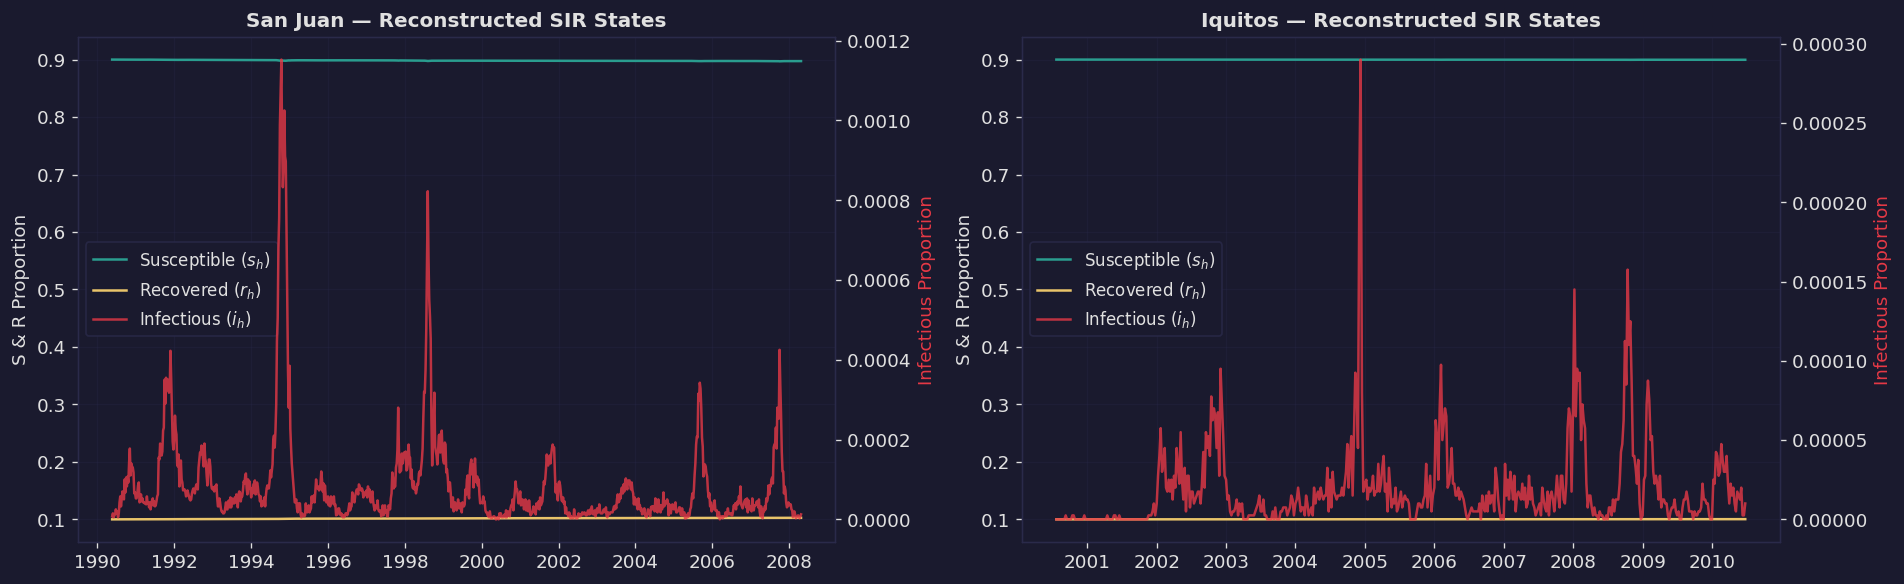

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (dfc, code) in zip(axes, [(df_sj_states, 'sj'), (df_iq_states, 'iq')]):
    ax.plot(dfc['week_start_date'], dfc['s_h'], label='Susceptible ($s_h$)', color='#2A9D8F')
    ax.plot(dfc['week_start_date'], dfc['r_h'], label='Recovered ($r_h$)', color='#E9C46A')
    
    # Plot I on a secondary axis because it's orders of magnitude smaller
    ax2 = ax.twinx()
    ax2.plot(dfc['week_start_date'], dfc['i_h'], label='Infectious ($i_h$)', color=PALETTE['sj'], alpha=0.8)
    ax2.set_ylabel('Infectious Proportion', color=PALETTE['sj'])
    
    ax.set_title(f'{city_label(code)} — Reconstructed SIR States', fontsize=12)
    ax.set_ylabel('S & R Proportion')
    ax.grid(True, alpha=0.3)
    
    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, loc='center left')

plt.tight_layout()
save_fig(fig, '03_reconstructed_states')
plt.show()

## 3 · Smoothing (Savitzky-Golay Filter)

We apply a Savitzky-Golay filter to $s_h$, $i_h$, and $r_h$ to suppress high-frequency noise before differentiation.
Blueprint parameters: `window_length=9`, `polyorder=3`.

  ✅ Saved → D:\Mayank\dengue-sindy-env-dynamics\figures\03_smoothed_states.png


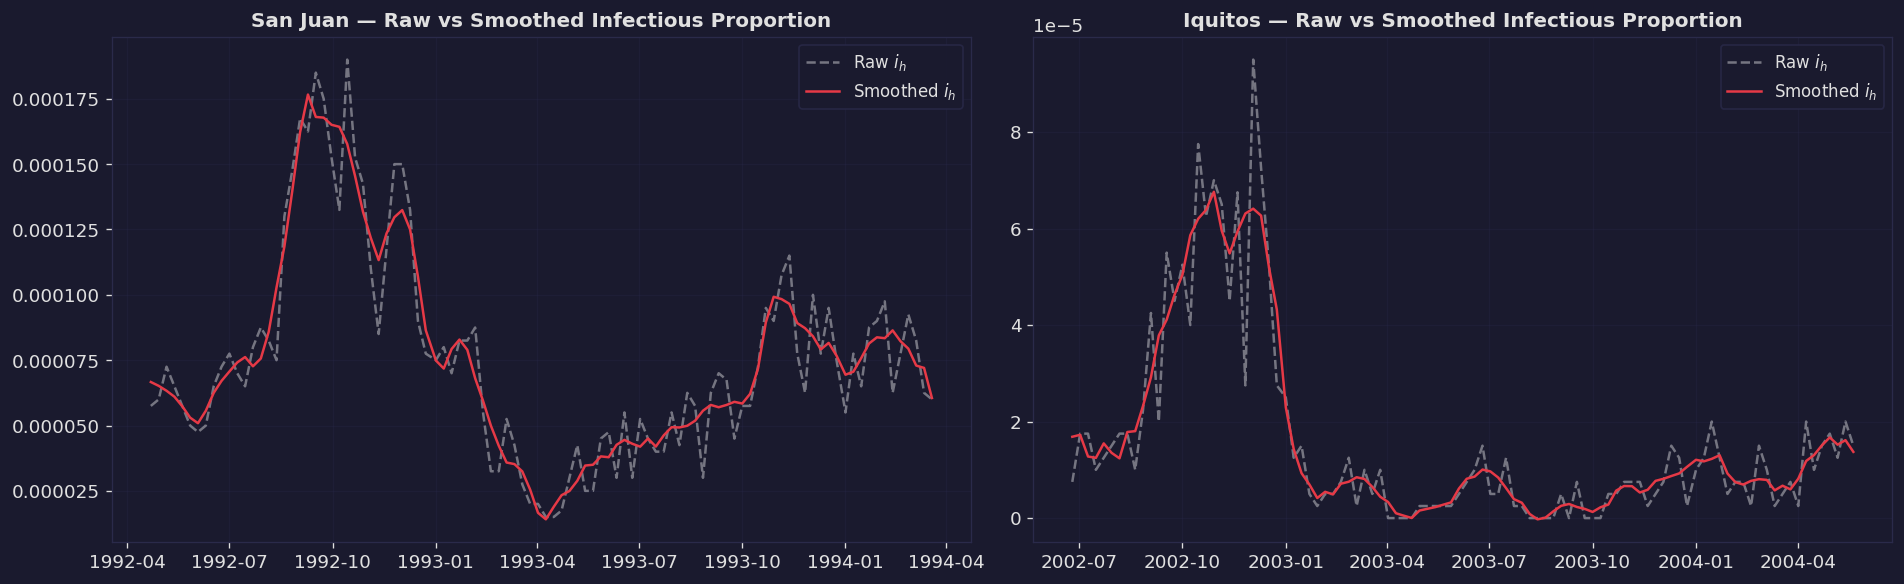

In [5]:
def smooth_states(df, window=9, poly=3):
    """Apply Savitzky-Golay filter to the state variables."""
    out = df.copy()
    for state in ['s_h', 'i_h', 'r_h']:
        out[f'{state}_smooth'] = savgol_filter(out[state], window_length=window, polyorder=poly)
    return out

df_sj_smooth = smooth_states(df_sj_states)
df_iq_smooth = smooth_states(df_iq_states)

# Plot Raw vs Smoothed I(t) to verify
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (dfc, code) in zip(axes, [(df_sj_smooth, 'sj'), (df_iq_smooth, 'iq')]):
    # Zoom in on an interesting window
    subset = dfc.iloc[100:200]
    ax.plot(subset['week_start_date'], subset['i_h'], label='Raw $i_h$', color='white', alpha=0.4, linestyle='--')
    ax.plot(subset['week_start_date'], subset['i_h_smooth'], label='Smoothed $i_h$', color=PALETTE['sj'], linewidth=1.5)
    
    ax.set_title(f'{city_label(code)} — Raw vs Smoothed Infectious Proportion', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_fig(fig, '03_smoothed_states')
plt.show()

## 4 · Numerical Derivative Estimation

Compute time derivatives using `numpy.gradient` with `dt=1` week.

  ✅ Saved → D:\Mayank\dengue-sindy-env-dynamics\figures\03_derivatives.png


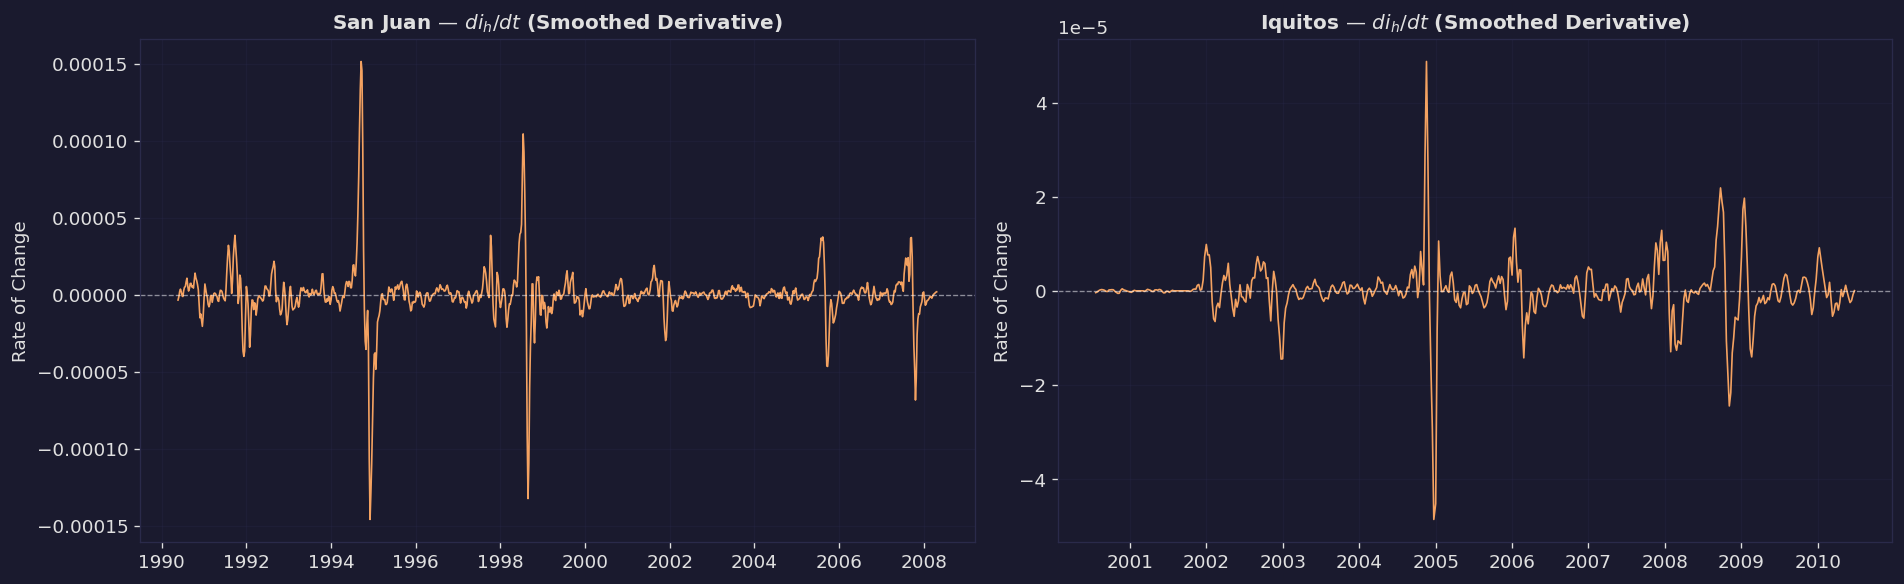

In [6]:
def estimate_derivatives(df):
    """Compute dt using central differences via np.gradient."""
    out = df.copy()
    dt = 1.0  # 1 week
    
    for state in ['s_h', 'i_h', 'r_h']:
        # We differentiate the smoothed signal
        out[f'd{state}_dt'] = np.gradient(out[f'{state}_smooth'], dt)
        
    return out

df_sj_final = estimate_derivatives(df_sj_smooth)
df_iq_final = estimate_derivatives(df_iq_smooth)

# Verify derivatives
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (dfc, code) in zip(axes, [(df_sj_final, 'sj'), (df_iq_final, 'iq')]):
    ax.plot(dfc['week_start_date'], dfc['di_h_dt'], color=PALETTE['accent'], linewidth=1)
    ax.axhline(0, color='white', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.set_title(f'{city_label(code)} — $di_h/dt$ (Smoothed Derivative)', fontsize=12)
    ax.set_ylabel('Rate of Change')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_fig(fig, '03_derivatives')
plt.show()

## 5 · Save Extracted Dynamics Data

Save the final DataFrame containing the raw states, smoothed states, and derivatives.

In [7]:
df_sj_final.to_csv('../data_processed/sj_dynamics.csv', index=False)
df_iq_final.to_csv('../data_processed/iq_dynamics.csv', index=False)

print('✅ Saved dynamics data for both cities.')
print(f'Output shape SJ: {df_sj_final.shape}')
print(f'Output columns: {list(df_sj_final.columns)}')

✅ Saved dynamics data for both cities.
Output shape SJ: (933, 24)
Output columns: ['city', 'year', 'weekofyear', 'week_start_date', 'total_cases', 'T', 'P', 'H', 'V', 'T_lag1', 'P_lag1', 'P_lag2', 'P_lag3', 'sin_season', 'cos_season', 'i_h', 'r_h', 's_h', 's_h_smooth', 'i_h_smooth', 'r_h_smooth', 'ds_h_dt', 'di_h_dt', 'dr_h_dt']
